In [2]:
import os
print(os.getcwd())

C:\Users\nikhi\MeetingLens\notebooks


In [3]:
import os
os.chdir(r"C:\Users\nikhi\MeetingLens")
print(os.getcwd())

C:\Users\nikhi\MeetingLens


In [4]:
import json
import os
import pandas as pd
from collections import Counter, defaultdict

# Load all downloaded meeting files
meetings = {}
ami_dir  = "data/raw/ami"

for filename in sorted(os.listdir(ami_dir)):
    if not filename.endswith(".json"):
        continue
    with open(os.path.join(ami_dir, filename), encoding="utf-8") as f:
        m = json.load(f)
    meetings[m["meeting_id"]] = m

print(f"Total meetings loaded: {len(meetings)}")
print()

# Count by type
type_counts = Counter(m["meeting_type"] for m in meetings.values())
for mtype, count in sorted(type_counts.items()):
    print(f"  {mtype} meetings: {count}")

print()
print("First 10 meeting IDs:")
for mid in list(meetings.keys())[:10]:
    m = meetings[mid]
    print(f"  {mid}: {m['n_utterances']} utterances, "
          f"{m['n_speakers']} speakers, "
          f"{m['total_words']} words")

Total meetings loaded: 171

  ES meetings: 60
  IS meetings: 38
  OTHER meetings: 33
  TS meetings: 40

First 10 meeting IDs:
  EN2001a: 1022 utterances, 5 speakers, 16351 words
  EN2001b: 585 utterances, 4 speakers, 10010 words
  EN2001d: 720 utterances, 5 speakers, 10259 words
  EN2001e: 831 utterances, 5 speakers, 12881 words
  EN2002a: 1036 utterances, 4 speakers, 7621 words
  EN2002b: 672 utterances, 4 speakers, 6064 words
  EN2002c: 1007 utterances, 3 speakers, 10731 words
  EN2002d: 959 utterances, 4 speakers, 7830 words
  EN2003a: 492 utterances, 3 speakers, 6407 words
  EN2004a: 989 utterances, 4 speakers, 10051 words


In [5]:
# Pick one meeting to read in detail
meeting = meetings["ES2002a"]

print(f"Meeting ID   : {meeting['meeting_id']}")
print(f"Meeting type : {meeting['meeting_type']}")
print(f"Utterances   : {meeting['n_utterances']}")
print(f"Speakers     : {meeting['n_speakers']}")
print(f"Total words  : {meeting['total_words']}")
print()
print("=" * 55)
print("TRANSCRIPT (first 25 utterances)")
print("=" * 55)
print()

for i, utt in enumerate(meeting["utterances"][:25]):
    print(f"[{utt['speaker']}] {utt['text']}")
    print()

Meeting ID   : ES2002a
Meeting type : ES
Utterances   : 230
Speakers     : 4
Total words  : 2611

TRANSCRIPT (first 25 utterances)

[FEE005] OKAY RIGHT UM WELL THIS IS THE KICK OFF MEETING FOR OUR OUR PROJECT UM AND UM THIS IS JUST WHAT WE'RE GONNA BE DOING OVER THE NEXT TWENTY FIVE MINUTES

[MEE008] MM-HMM

[FEE005] UM SO FIRST OF ALL JUST TO KIND OF MAKE SURE THAT WE ALL KNOW EACH OTHER I'M LAURA AND I'M THE PROJECT MANAGER DO YOU WANT TO INTRODUCE YOURSELF AGAIN

[MEE008] GREAT

[MEE006] HI I'M DAVID AND I'M SUPPOSED TO BE AN INDUSTRIAL DESIGNER

[FEE005] OKAY

[MEE008] AND I'M ANDREW AND I'M UH OUR MARKETING

[MEE007] UM I'M CRAIG AND I'M USER INTERFACE

[MEE008] EXPERT

[FEE005] GREAT OKAY UM SO WE'RE DESIGNING A NEW REMOTE CONTROL AND UM OH I HAVE TO RECORD WHO'S HERE ACTUALLY SO THAT'S DAVID ANDREW AND CRAIG ISN'T IT AND YOU ALL ARRIVED ON TIME UM YEAH SO DES UH DESIGN A NEW REMOTE CONTROL UM AS YOU CAN SEE IT'S SUPPOSED TO BE ORIGINAL TRENDY AND USER FRIENDLY UM SO THAT'S KIND 

In [6]:
# Analyse how much each speaker talked in this meeting
utterances   = meeting["utterances"]
words_per_spk = defaultdict(int)
utts_per_spk  = defaultdict(int)

for utt in utterances:
    words_per_spk[utt["speaker"]] += utt["word_count"]
    utts_per_spk[utt["speaker"]]  += 1

total_words = sum(words_per_spk.values())

print(f"SPEAKER DOMINANCE ANALYSIS — {meeting['meeting_id']}")
print("=" * 55)
print()
print(f"{'Speaker':<12} {'Words':>6} {'Talk%':>7} {'Utterances':>11}  Bar")
print("-" * 55)

for spk, wc in sorted(words_per_spk.items(), key=lambda x: -x[1]):
    pct = wc / total_words * 100
    bar = "█" * int(pct / 2.5)
    print(f"{spk:<12} {wc:>6} {pct:>7.1f}% {utts_per_spk[spk]:>11}  {bar}")

# Speaker Dominance Score (SDS)
# SDS = max talk% divided by average talk%
# SDS = 1.0 means everyone talks equally
# SDS > 1.5 means one person is talking significantly more
# SDS > 2.0 means one person completely dominates
pcts      = [wc / total_words * 100 for wc in words_per_spk.values()]
avg_pct   = sum(pcts) / len(pcts)
sds       = max(pcts) / avg_pct

print()
print(f"Speaker Dominance Score (SDS) = {sds:.3f}")
if sds > 2.0:
    print("  WARNING: Severe communication imbalance detected")
elif sds > 1.5:
    print("  NOTICE: One speaker is significantly more dominant")
else:
    print("  OK: Participation is reasonably balanced")

SPEAKER DOMINANCE ANALYSIS — ES2002a

Speaker       Words   Talk%  Utterances  Bar
-------------------------------------------------------
FEE005         1303    49.9%          96  ███████████████████
MEE008          993    38.0%          98  ███████████████
MEE006          233     8.9%          29  ███
MEE007           82     3.1%           7  █

Speaker Dominance Score (SDS) = 1.996
  NOTICE: One speaker is significantly more dominant


In [7]:
import re

# These patterns identify utterances that are likely action items
# Based on Purver et al. 2007 - "Detecting Action Items in Multi-Party Meetings"
ACTION_PATTERNS = [
    r'\bwill\b',
    r'\b(going|plan(ning)?)\s+to\b',
    r'\b(need|have|has)\s+to\b',
    r'\bmust\b',
    r'\bshould\b',
    r'\bcan\s+you\b',
    r'\bcould\s+you\b',
    r'\bplease\b',
    r'\bby\s+(monday|tuesday|wednesday|thursday|friday|tomorrow|next week)\b',
    r'\b(send|prepare|update|complete|finish|submit|review|check|draft)\b',
    r'\baction\s+item\b',
    r'\btask\b',
]

def is_action_item(text):
    t = text.lower()
    return any(re.search(pat, t) for pat in ACTION_PATTERNS)

# Find action items in the meeting
print(f"POTENTIAL ACTION ITEMS — {meeting['meeting_id']}")
print("=" * 55)
print()

action_items = []
for utt in meeting["utterances"]:
    if is_action_item(utt["text"]):
        action_items.append(utt)

print(f"Found {len(action_items)} potential action items "
      f"out of {len(meeting['utterances'])} total utterances")
print(f"Action item rate: {len(action_items)/len(meeting['utterances'])*100:.1f}%")
print()

for ai in action_items[:10]:
    print(f"[{ai['speaker']}]: {ai['text']}")
    print()

POTENTIAL ACTION ITEMS — ES2002a

Found 16 potential action items out of 230 total utterances
Action item rate: 7.0%

[FEE005]: GREAT OKAY UM SO WE'RE DESIGNING A NEW REMOTE CONTROL AND UM OH I HAVE TO RECORD WHO'S HERE ACTUALLY SO THAT'S DAVID ANDREW AND CRAIG ISN'T IT AND YOU ALL ARRIVED ON TIME UM YEAH SO DES UH DESIGN A NEW REMOTE CONTROL UM AS YOU CAN SEE IT'S SUPPOSED TO BE ORIGINAL TRENDY AND USER FRIENDLY UM SO THAT'S KIND OF OUR OUR BRIEF AS IT WERE UM AND SO THERE ARE THREE DIFFERENT STAGES TO THE DESIGN UM I'M NOT REALLY SURE WHAT WHAT YOU GUYS HAVE ALREADY RECEIVED UM IN YOUR EMAILS WHAT DID YOU GET

[MEE008]: I WILL GO THAT'S FINE

[FEE005]: ACH WHY NOT WE MIGHT HAVE TO GET YOU UP AGAIN THEN

[FEE005]: I DON'T KNOW WHAT MINE IS I'M GONNA HAVE TO THINK ON THE SPOT NOW

[FEE005]: YEAH MAYBE MAYBE RIGHT UM WHERE DID YOU FIND THIS JUST DOWN HERE YEAH OKAY UM WHAT ARE WE DOING NEXT UH UM OKAY UH WE NOW NEED TO DISCUSS THE PROJECT FINANCE UM SO ACCORDING TO THE BRIEF UM WE'RE GO

In [8]:
# Hedging words are linguistic markers of uncertainty and stress
# Research shows: more hedging = higher burnout risk
# (Calvo et al. 2017 - "Natural Language Processing in Mental Health")

HEDGING_WORDS = [
    "maybe", "perhaps", "possibly", "probably",
    "i think", "i guess", "i suppose", "i believe",
    "not sure", "uncertain", "unclear",
    "might", "could", "sort of", "kind of",
    "roughly", "approximately", "seems like",
    "hard to say", "i don't know", "we'll see"
]

def find_hedging(text):
    t = text.lower()
    return [hw for hw in HEDGING_WORDS if hw in t]

# Analyse hedging across ALL meetings (not just one)
print("HEDGING LANGUAGE ANALYSIS ACROSS ALL MEETINGS")
print("=" * 55)
print()

all_speaker_hedging = defaultdict(lambda: {"count": 0, "utterances": 0})
hedging_examples    = []

for mid, mtg in meetings.items():
    for utt in mtg["utterances"]:
        hedges = find_hedging(utt["text"])
        spk_key = f"{mid}::{utt['speaker']}"
        all_speaker_hedging[spk_key]["utterances"] += 1
        if hedges:
            all_speaker_hedging[spk_key]["count"] += len(hedges)
            if len(hedging_examples) < 8:
                hedging_examples.append({
                    "meeting": mid,
                    "speaker": utt["speaker"],
                    "text":    utt["text"][:90],
                    "hedges":  hedges
                })

# Show examples
print("Examples of hedging language detected:")
print()
for ex in hedging_examples:
    print(f"  [{ex['meeting']}][{ex['speaker']}]")
    print(f"  Text   : {ex['text']}...")
    print(f"  Hedging: {ex['hedges']}")
    print()

# Top hedging speakers
print("Top 10 highest-hedging speakers (burnout risk candidates):")
print()
top_hedgers = sorted(
    [(k, v["count"] / max(v["utterances"], 1))
     for k, v in all_speaker_hedging.items()],
    key=lambda x: -x[1]
)[:10]

for spk_key, rate in top_hedgers:
    mid, spk = spk_key.split("::")
    print(f"  {mid} / {spk}: {rate:.3f} hedges per utterance")

HEDGING LANGUAGE ANALYSIS ACROSS ALL MEETINGS

Examples of hedging language detected:

  [EN2001a][MEE068]
  Text   : LIKE DUPLICATION OF EFFORT AND STUFF AND UM YEAH HE WAS SAYING THAT WE SHOULD MAYBE UH THI...
  Hedging: ['maybe']

  [EN2001a][MEE068]
  Text   : YEAH SO WE SHOULD PROBABLY PRIORITIZE OUR PACKAGES...
  Hedging: ['probably']

  [EN2001a][MEO069]
  Text   : THEN WE SHOULD PROBABLY BE ABLE TO BASICALLY THAT MEANS WE FOCUS ON ON THE INTERFACE FIRST...
  Hedging: ['probably', 'sort of']

  [EN2001a][FEO066]
  Text   : YEAH I MEAN IF WE JUST WANT TO HAVE UM SOME DATA FOR THE USER FACE COULD EVEN BE RANDOM DA...
  Hedging: ['could']

  [EN2001a][MEO069]
  Text   : NO BUT ALSO I MIGHT LIKE THE THE SIMILARITY THING LIKE MY JUST MY MATRIX ITSELF FOR MY STU...
  Hedging: ['might']

  [EN2001a][MEO069]
  Text   : I C I I THINK I CAN DO THAT FAIRLY QUICKLY BECAUSE I HAVE THE ALGORITHMS...
  Hedging: ['i think']

  [EN2001a][MEO069]
  Text   : YEAH I THINK TODAY'S MEETING IS REALLY 

In [9]:
# Final comprehensive statistics for your report
print("FULL AMI CORPUS — STATISTICS FOR MIDWAY REPORT")
print("=" * 55)
print()

stats_df = pd.read_csv("data/processed/ami_corpus_stats.csv")

print(f"Total meetings          : {len(stats_df)}")
print(f"Total utterances        : {stats_df['n_utterances'].sum():,}")
print(f"Total words             : {stats_df['total_words'].sum():,}")
print()
print(f"Average per meeting:")
print(f"  Utterances : {stats_df['n_utterances'].mean():.1f}")
print(f"  Words      : {stats_df['total_words'].mean():.1f}")
print(f"  Speakers   : {stats_df['n_speakers'].mean():.1f}")
print()
print("By meeting type:")
for mtype, grp in stats_df.groupby("meeting_type"):
    print(f"  {mtype}: {len(grp)} meetings | "
          f"avg {grp['n_utterances'].mean():.0f} utterances | "
          f"avg {grp['n_speakers'].mean():.1f} speakers")

print()
print("This data will be reported as Table 1 in your research paper.")
print()

# Count action items across the full corpus
total_action_items = 0
for mid, mtg in meetings.items():
    for utt in mtg["utterances"]:
        if is_action_item(utt["text"]):
            total_action_items += 1

total_utterances = sum(m["n_utterances"] for m in meetings.values())
print(f"Estimated action items  : {total_action_items:,}")
print(f"Action item rate        : {total_action_items/total_utterances*100:.1f}% of all utterances")
print()
print("Screenshot this cell output for your report — this is Table 1: Dataset Statistics")

FULL AMI CORPUS — STATISTICS FOR MIDWAY REPORT

Total meetings          : 171
Total utterances        : 89,528
Total words             : 987,512

Average per meeting:
  Utterances : 523.6
  Words      : 5774.9
  Speakers   : 4.0

By meeting type:
  ES: 60 meetings | avg 385 utterances | avg 4.0 speakers
  IS: 38 meetings | avg 388 utterances | avg 4.0 speakers
  OTHER: 33 meetings | avg 833 utterances | avg 3.9 speakers
  TS: 40 meetings | avg 604 utterances | avg 4.0 speakers

This data will be reported as Table 1 in your research paper.

Estimated action items  : 8,376
Action item rate        : 9.4% of all utterances

Screenshot this cell output for your report — this is Table 1: Dataset Statistics


In [2]:
import os
os.chdir(r"C:\Users\nikhi\MeetingLens")

In [3]:
import os
os.chdir(r"C:\Users\nikhi\MeetingLens")

import pandas as pd

train_df = pd.read_csv("data/processed/train_labeled.csv")
val_df   = pd.read_csv("data/processed/validation_labeled.csv")
test_df  = pd.read_csv("data/processed/test_labeled.csv")

summary_rows = []

for name, df in [
    ("Train", train_df),
    ("Validation", val_df),
    ("Test", test_df)
]:

    n    = len(df)
    n_ai = df["action_item"].sum()
    n_d  = df["decision"].sum()
    n_h  = (df["hedging_score"] > 0).sum()

    summary_rows.append({
        "Split": name,
        "Total Utterances": n,
        "Action Items": n_ai,
        "Decisions": n_d,
        "Hedging": n_h
    })

summary_df = pd.DataFrame(summary_rows)

print(summary_df)

        Split  Total Utterances  Action Items  Decisions  Hedging
0       Train             35660          7871        115    11391
1  Validation              5288          1033         16     1730
2        Test             10109          2270         23     3324


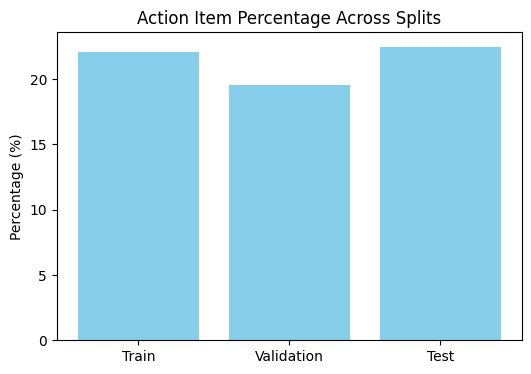

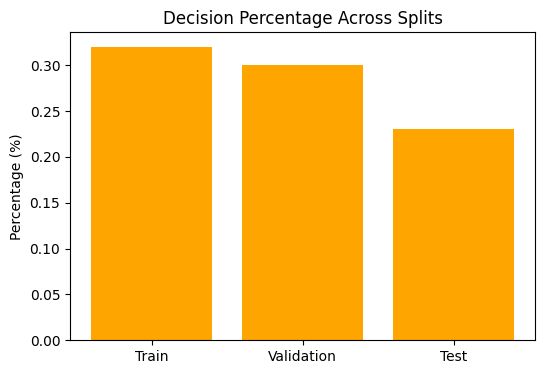

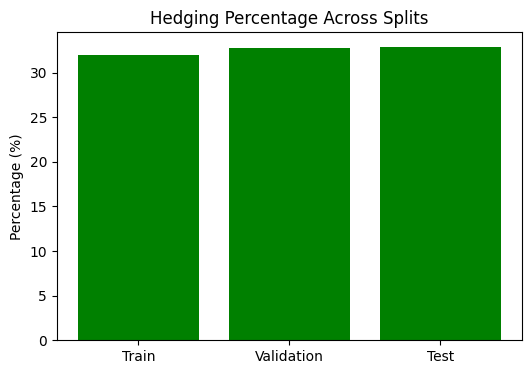

In [9]:
import matplotlib.pyplot as plt

# -----------------------------
# ACTION ITEMS
# -----------------------------
plt.figure(figsize=(6,4))

plt.bar(
    summary_df["Split"],
    summary_df["Action %"],
    color="skyblue"
)

plt.title("Action Item Percentage Across Splits")
plt.ylabel("Percentage (%)")

plt.show()


# -----------------------------
# DECISIONS
# -----------------------------
plt.figure(figsize=(6,4))

plt.bar(
    summary_df["Split"],
    summary_df["Decision %"],
    color="orange"
)

plt.title("Decision Percentage Across Splits")
plt.ylabel("Percentage (%)")

plt.show()


# -----------------------------
# HEDGING
# -----------------------------
plt.figure(figsize=(6,4))

plt.bar(
    summary_df["Split"],
    summary_df["Hedging %"],
    color="green"
)

plt.title("Hedging Percentage Across Splits")
plt.ylabel("Percentage (%)")

plt.show()

In [10]:
# CLASS IMBALANCE — critical to understand for your mentor
# In real meetings ~15-25% of utterances are action items
# This means for every 1 action item, there are ~4-6 non-action items
# The model must learn from this imbalanced data
# We handle this with CLASS WEIGHTS during training (Day 3)

n_pos = train_df["action_item"].sum()
n_neg = (train_df["action_item"] == 0).sum()
ratio = n_neg / n_pos

print("CLASS IMBALANCE ANALYSIS")
print("=" * 45)
print()
print(f"  Action items (positive class) : {n_pos:,}")
print(f"  Non-action items (negative)   : {n_neg:,}")
print(f"  Imbalance ratio               : 1 : {ratio:.1f}")
print()
print("  How we handle this:")
print("  → Class weights during training")
print(f"    weight_class_0 = {n_pos/(n_pos+n_neg):.4f}")
print(f"    weight_class_1 = {n_neg/(n_pos+n_neg):.4f}")
print()
print("  This tells the model: 'pay more attention to the rare class'")
print("  Without this, the model would just predict 0 for everything")
print("  and still get ~80% accuracy — which is useless.")

CLASS IMBALANCE ANALYSIS

  Action items (positive class) : 7,871
  Non-action items (negative)   : 27,789
  Imbalance ratio               : 1 : 3.5

  How we handle this:
  → Class weights during training
    weight_class_0 = 0.2207
    weight_class_1 = 0.7793

  This tells the model: 'pay more attention to the rare class'
  Without this, the model would just predict 0 for everything
  and still get ~80% accuracy — which is useless.


In [3]:
import os
os.chdir(r"C:\Users\nikhi\MeetingLens")

import pandas as pd

train_df = pd.read_csv("data/processed/train_labeled.csv")

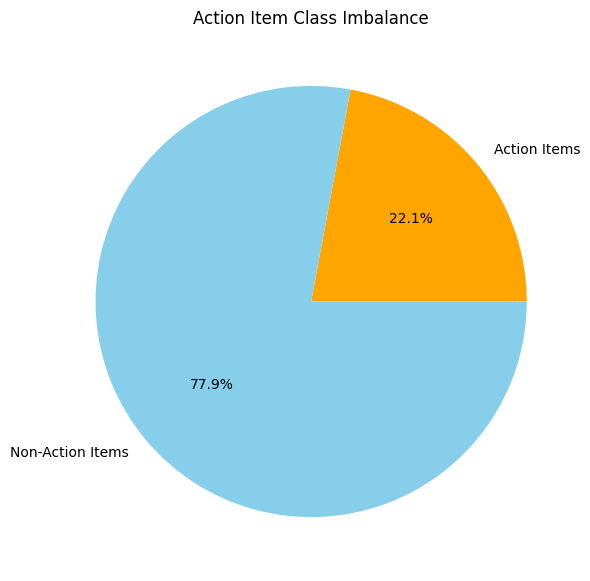

In [4]:
import os
os.chdir(r"C:\Users\nikhi\MeetingLens")

import pandas as pd
import matplotlib.pyplot as plt

# ----------------------------------------
# Load dataset
# ----------------------------------------

train_df = pd.read_csv("data/processed/train_labeled.csv")

# ----------------------------------------
# Calculate class counts
# ----------------------------------------

n_pos = train_df["action_item"].sum()

n_neg = (train_df["action_item"] == 0).sum()

labels = ["Action Items", "Non-Action Items"]

sizes = [n_pos, n_neg]

# ----------------------------------------
# PIE CHART
# ----------------------------------------

plt.figure(figsize=(7,7))

plt.pie(
    sizes,
    labels=labels,
    autopct='%1.1f%%',
    colors=["orange", "skyblue"]
)

plt.title("Action Item Class Imbalance")

plt.show()